In [1]:
import os
from random import shuffle
import numpy as np
import matplotlib.pyplot as plt
import umap.umap_ as umap

import torch
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms

In [2]:
device = torch.device(0)

In [3]:
model = models.resnet18(pretrained = False)
model.fc = torch.nn.Linear(in_features=512, out_features=10, bias=True)
model = model.to(device)
print(model)

/home/eslab/anaconda3/envs/facerec_new/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/eslab/anaconda3/envs/facerec_new/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [4]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))])

invTrans = transforms.Compose(
    [transforms.Normalize(mean=[0., 0., 0.], std=[ 1/0.5, 1/0.5, 1/0.5 ]),
    transforms.Normalize(mean=[ -0.5, -0.5, -0.5 ],std = [ 1., 1., 1. ])])

transformNorm = transforms.Compose(
    [transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))])

batch_size = 64

trainset = torchvision.datasets.CIFAR10(root='./dataa', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./dataa', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

Files already downloaded and verified
Files already downloaded and verified


In [5]:
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [6]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)

In [7]:
epochs = 30
best_train_loss = np.inf
for epoch in range(epochs):
    training_loss = 0.0
    model.train()
    for i, data in enumerate(trainloader):
        img, gt = data
        
        optimizer.zero_grad()
        output = model(img.to(device))
        loss = criterion(output, gt.to(device))
        loss.backward()
        optimizer.step()
        
        training_loss += loss.item()
        
    print(f'[{epoch + 1}] loss: {np.mean(training_loss/i):.3f}')
        

    

[1] loss: 1.954
[2] loss: 1.367
[3] loss: 1.163
[4] loss: 1.006
[5] loss: 0.883
[6] loss: 0.787
[7] loss: 0.690
[8] loss: 0.610
[9] loss: 0.559
[10] loss: 0.474
[11] loss: 0.402
[12] loss: 0.345
[13] loss: 0.298
[14] loss: 0.256
[15] loss: 0.222
[16] loss: 0.183
[17] loss: 0.155
[18] loss: 0.144
[19] loss: 0.138
[20] loss: 0.111
[21] loss: 0.092
[22] loss: 0.086
[23] loss: 0.087
[24] loss: 0.059
[25] loss: 0.062
[26] loss: 0.058
[27] loss: 0.052
[28] loss: 0.050
[29] loss: 0.047
[30] loss: 0.049


In [8]:
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}
model.eval()
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = model(images.to(device))
        _, predictions = torch.max(outputs, 1)
        for label, prediction in zip(labels.to(device), predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1
            
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 84.6 %
Accuracy for class: car   is 81.4 %
Accuracy for class: bird  is 59.1 %
Accuracy for class: cat   is 58.6 %
Accuracy for class: deer  is 70.6 %
Accuracy for class: dog   is 61.7 %
Accuracy for class: frog  is 80.1 %
Accuracy for class: horse is 79.0 %
Accuracy for class: ship  is 83.2 %
Accuracy for class: truck is 80.3 %


# extract resnet18 features and apply umap on test set and visualize the results

In [9]:
def get_resnet_embedding(model, batch):
    x = model.maxpool(model.relu(model.bn1(model.conv1(batch))))
    x = model.layer1(x)
    x = model.layer2(x)
    x = model.layer3(x)
    x = model.avgpool(model.layer4(x))
    return x

In [10]:
model.eval()
test_features = None
test_labels = torch.empty(0, dtype=torch.int64)
with torch.no_grad():
    for i, data in enumerate(testloader):
        img, label = data
        img, label = img.to(device), label.to(device)
        emb = get_resnet_embedding(model, img)
        if test_features is None:
            test_features = emb.detach().cpu()
        else:
            test_features = torch.cat((test_features, emb.detach().cpu()), dim = 0)
        
        test_labels = torch.cat((test_labels, label.detach().cpu()))

In [11]:
test_features = test_features.squeeze()
print(test_features.shape)

torch.Size([10000, 512])


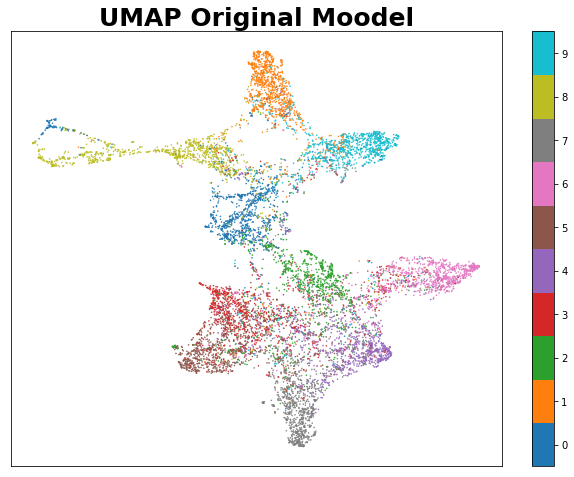

In [12]:
params = {'n_neighbors':5,
                'min_dist':0.1,
                'n_components':2,
                'metric':'euclidean'}

fig, ax = plt.subplots(figsize=(11,8), constrained_layout=False)
ax.set(xticks=[], yticks=[])

umap_embedding = umap.UMAP(n_neighbors=params['n_neighbors'], min_dist=params['min_dist'], n_components=params['n_components'], metric=params['metric']).fit_transform(test_features.numpy())
scatter = ax.scatter(x = umap_embedding[:,0], y = umap_embedding[:,1], s=0.3, c=test_labels, cmap='tab10')

cbar = plt.colorbar(scatter, boundaries=np.arange(11)-0.5)
cbar.set_ticks(np.arange(10))
cbar.set_ticklabels(np.arange(10))

plt.title('UMAP Original Moodel', fontsize=25, fontweight='bold')
plt.show()

# apply boundary shrink method

In [13]:
ship_class = 8
forget_sample_count = 3000

forget_indices = []

for i, data in enumerate(trainset):
    _, label = data
    if label == ship_class:
        if len(forget_indices) >= 3000:
            break
        forget_indices.append(i)

import torch.utils
import torch.utils.data
from torch.utils.data.sampler import SubsetRandomSampler



forget_train_sampler = SubsetRandomSampler(forget_indices)
forget_trainset = torch.utils.data.DataLoader(trainset, batch_size=64, sampler=forget_train_sampler)

In [14]:
ship_class = 8
# forget_sample_count = 3000

forget_indices_test = []

for i, data in enumerate(testset):
    _, label = data
    if label == ship_class:
        # if len(forget_indices) >= 3000:
        #     break
        
        forget_indices_test.append(i)

import torch.utils
import torch.utils.data
from torch.utils.data.sampler import SubsetRandomSampler



forget_test_sampler = SubsetRandomSampler(forget_indices_test)
forget_testloader = torch.utils.data.DataLoader(testset, batch_size=64, sampler=forget_test_sampler)

In [15]:
from copy import deepcopy
forget_model = deepcopy(model)

In [16]:
criterion_forget = torch.nn.CrossEntropyLoss()
optimizer_forget = torch.optim.SGD(forget_model.parameters(), lr=0.0001, momentum=0.9)

In [17]:
def generate_adversarial_attacks(forget_samples, label, model, loss_function, epsilon):
    model.zero_grad()
    forget_samples.requires_grad = True
    output = model(forget_samples)
    loss = loss_function(output, label)
    loss.backward()
    
    sign_gradient_loss = forget_samples.grad.data.sign()
    
    attack_sample = forget_samples + epsilon * sign_gradient_loss
    
    output = model(attack_sample)
    pred = torch.nn.functional.softmax(output, dim=-1)
    _, updated_label = torch.max(output, 1)
    
    return attack_sample.detach(), pred

In [18]:
for epoch in range(20):
    training_loss = 0.0
    forget_model.train()
    for i, data in enumerate(forget_trainset):
        img, label = data
        
        img = img.to(device)
        label = label.to(device)
        
        attack_img, updated_label = generate_adversarial_attacks(img, label, model, criterion, 0.1)
        
        optimizer_forget.zero_grad()
        output = forget_model(img)
        loss = criterion_forget(output, updated_label)
        loss.backward()
        optimizer_forget.step()
        
        training_loss += loss.item()
    
    print(f'[{epoch + 1}] loss: {(training_loss/i):.3f}')

[1] loss: 4.147
[2] loss: 3.800
[3] loss: 3.503
[4] loss: 3.213
[5] loss: 3.000
[6] loss: 2.839
[7] loss: 2.593
[8] loss: 2.416
[9] loss: 2.287
[10] loss: 2.150
[11] loss: 2.004
[12] loss: 1.920
[13] loss: 1.801
[14] loss: 1.748
[15] loss: 1.647
[16] loss: 1.564
[17] loss: 1.524
[18] loss: 1.442
[19] loss: 1.397
[20] loss: 1.356


In [19]:
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}
forget_model.eval()
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = forget_model(images.to(device))
        _, predictions = torch.max(outputs, 1)
        for label, prediction in zip(labels.to(device), predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1

for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 79.2 %
Accuracy for class: car   is 74.3 %
Accuracy for class: bird  is 50.2 %
Accuracy for class: cat   is 43.9 %
Accuracy for class: deer  is 72.5 %
Accuracy for class: dog   is 61.4 %
Accuracy for class: frog  is 83.9 %
Accuracy for class: horse is 83.4 %
Accuracy for class: ship  is 8.1 %
Accuracy for class: truck is 80.1 %


In [20]:
forget_model.eval()
test_features_fmodel = None
test_labels_fmodel = torch.empty(0, dtype=torch.int64)
with torch.no_grad():
    for i, data in enumerate(testloader):
        img, label = data
        img, label = img.to(device), label.to(device)
        emb = get_resnet_embedding(forget_model, img)
        if test_features_fmodel is None:
            test_features_fmodel = emb.detach().cpu()
        else:
            test_features_fmodel = torch.cat((test_features_fmodel, emb.detach().cpu()), dim = 0)
        
        test_labels_fmodel = torch.cat((test_labels_fmodel, label.detach().cpu()))

In [21]:
test_features_fmodel = test_features_fmodel.squeeze()

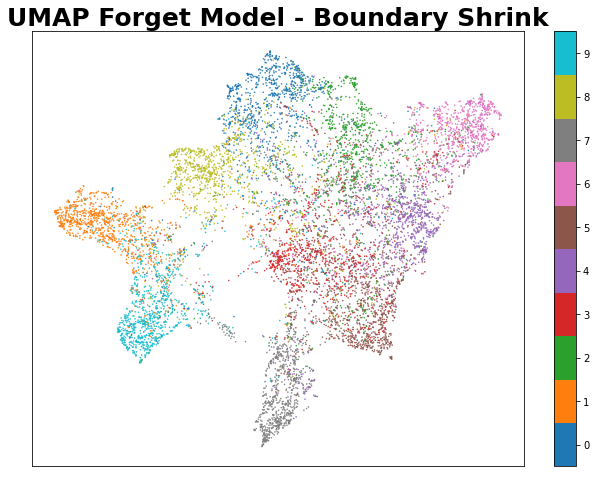

In [22]:
params = {'n_neighbors':5,
                'min_dist':0.1,
                'n_components':2,
                'metric':'euclidean'}

fig, ax = plt.subplots(figsize=(11,8), constrained_layout=False)
ax.set(xticks=[], yticks=[])

umap_embedding = umap.UMAP(n_neighbors=params['n_neighbors'], min_dist=params['min_dist'], n_components=params['n_components'], metric=params['metric']).fit_transform(test_features_fmodel.numpy())
scatter = ax.scatter(x = umap_embedding[:,0], y = umap_embedding[:,1], s=0.3, c=test_labels_fmodel, cmap='tab10')

cbar = plt.colorbar(scatter, boundaries=np.arange(11)-0.5)
cbar.set_ticks(np.arange(10))
cbar.set_ticklabels(np.arange(10))

plt.title('UMAP Forget Model - Boundary Shrink', fontsize=25, fontweight='bold')
plt.show()

# Step - 3
### using samples of all classes in boundary shrink method, to retain performance on all classes while corrupting the performance on the forget class

- create training dataloader
- should contain 2k samples of all retain classes - 0.2 percent of training data
- should contain 3k samples of forget class - 0.3 percent of forget class
- apply boundary shrink on forget class - while retaining performance on retain classes in a single pass

In [23]:
# create training dataloader
len(trainset.targets)

50000

In [24]:
len(forget_train_sampler.indices)

3000

In [25]:
ship_class = 8
forget_sample_count = 3000
retain_sample_count = 2000
data_len = {classname: 0 for classname in classes}

forget_retain_indices_train = []

for i, data in enumerate(trainset):
    _, label = data
    if label == ship_class:
        if data_len[classes[label]] >= forget_sample_count:
            continue
        forget_retain_indices_train.append(i)
        data_len[classes[label]] += 1
    else:
        if data_len[classes[label]] >= retain_sample_count:
            continue
        forget_retain_indices_train.append(i)
        data_len[classes[label]] += 1


shuffle(forget_retain_indices_train)
forget_retain_train_sampler = SubsetRandomSampler(forget_retain_indices_train)
forget_retain_trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, sampler=forget_retain_train_sampler)


In [26]:
from copy import deepcopy
forget_retain_model = deepcopy(model)
criterion_forget_retain = torch.nn.CrossEntropyLoss()
optimizer_forget_retain = torch.optim.SGD(forget_model.parameters(), lr=0.01, momentum=0.9)

In [27]:
def generate_adversarial_attacks_forget(forget_samples, label, model, loss_function, epsilon):
    model.zero_grad()
    
    forget_samples = forget_samples[None, :, :, :]
    forget_samples.requires_grad = True
    output = model(forget_samples)
    # print(forget_samples)
    # print(label)
    loss = loss_function(output, label)
    loss.backward()
    
    sign_gradient_loss = forget_samples.grad.data.sign()
    
    attack_sample = forget_samples + epsilon * sign_gradient_loss
    
    output = model(attack_sample)
    pred = torch.nn.functional.softmax(output, dim=-1)
    _, updated_label = torch.max(output, 1)
    
    return attack_sample.detach(), updated_label

In [28]:
for epoch in range(20):
    training_loss = 0.0
    forget_retain_model.train()
    for i, data in enumerate(forget_retain_trainloader):
        img, label = data
        
        img = img.to(device)
        label = label
        
        indices = torch.where(label == 8)[0]
        # print('indices')
        # print(indices)
        
        
        if indices is not None and len(indices) > 0:
            for ind in indices:
                attack_img, uplabel = generate_adversarial_attacks_forget(img[ind,:,:,:], torch.tensor([8]).to(device), model, criterion, 0.1)
                # print(uplabel)
                label[ind] = uplabel
        
        # if label.item() == 8:
        #     attack_img, label = generate_adversarial_attacks(img, label, model, criterion, 0.1)
        
        # print(img.shape)
        optimizer_forget_retain.zero_grad()
        output = forget_retain_model(img)
        loss = criterion_forget_retain(output, label.to(device))
        loss.backward()
        optimizer_forget_retain.step()
        
        training_loss += loss.item()
    
    print(f'[{epoch + 1}] loss: {(training_loss/i):.3f}')

[1] loss: 1.265
[2] loss: 1.250
[3] loss: 1.263
[4] loss: 1.252
[5] loss: 1.261
[6] loss: 1.255
[7] loss: 1.256
[8] loss: 1.258
[9] loss: 1.255
[10] loss: 1.260
[11] loss: 1.252
[12] loss: 1.267
[13] loss: 1.268
[14] loss: 1.263
[15] loss: 1.253
[16] loss: 1.258
[17] loss: 1.259
[18] loss: 1.260
[19] loss: 1.256
[20] loss: 1.265


In [29]:
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}
forget_retain_model.eval()
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = forget_retain_model(images.to(device))
        _, predictions = torch.max(outputs, 1)
        for label, prediction in zip(labels.to(device), predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1

for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 83.5 %
Accuracy for class: car   is 81.0 %
Accuracy for class: bird  is 61.4 %
Accuracy for class: cat   is 60.4 %
Accuracy for class: deer  is 69.0 %
Accuracy for class: dog   is 62.9 %
Accuracy for class: frog  is 78.1 %
Accuracy for class: horse is 80.0 %
Accuracy for class: ship  is 79.3 %
Accuracy for class: truck is 82.2 %


In [30]:
forget_retain_model.eval()
test_features_ftmodel = None
test_labels_ftmodel = torch.empty(0, dtype=torch.int64)
with torch.no_grad():
    for i, data in enumerate(testloader):
        img, label = data
        img, label = img.to(device), label.to(device)
        emb = get_resnet_embedding(forget_retain_model, img)
        if test_features_ftmodel is None:
            test_features_ftmodel = emb.detach().cpu()
        else:
            test_features_ftmodel = torch.cat((test_features_ftmodel, emb.detach().cpu()), dim = 0)
        
        test_labels_ftmodel = torch.cat((test_labels_ftmodel, label.detach().cpu()))

test_features_ftmodel = test_features_ftmodel.squeeze()

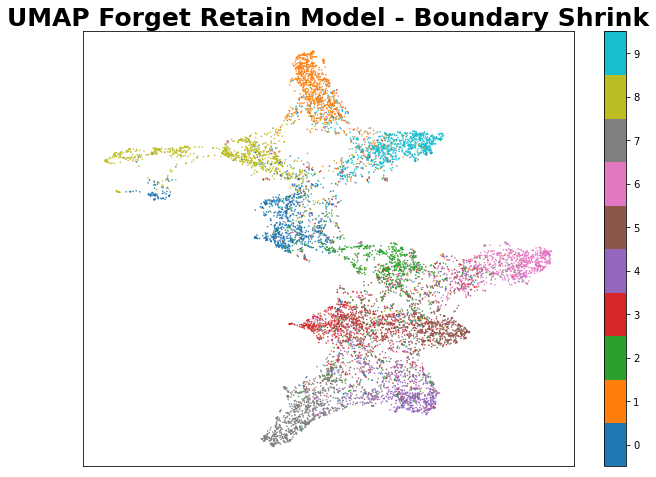

In [31]:
params = {'n_neighbors':5,
                'min_dist':0.1,
                'n_components':2,
                'metric':'euclidean'}

fig, ax = plt.subplots(figsize=(11,8), constrained_layout=False)
ax.set(xticks=[], yticks=[])

umap_embedding = umap.UMAP(n_neighbors=params['n_neighbors'], min_dist=params['min_dist'], n_components=params['n_components'], metric=params['metric']).fit_transform(test_features_ftmodel.numpy())
scatter = ax.scatter(x = umap_embedding[:,0], y = umap_embedding[:,1], s=0.3, c=test_labels_ftmodel, cmap='tab10')

cbar = plt.colorbar(scatter, boundaries=np.arange(11)-0.5)
cbar.set_ticks(np.arange(10))
cbar.set_ticklabels(np.arange(10))

plt.title('UMAP Forget Retain Model - Boundary Shrink', fontsize=25, fontweight='bold')
plt.show()